In [1]:
from Distribution import Distribution
from queue import PriorityQueue
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats

from joblib import Parallel, delayed
import multiprocessing
num_cores = multiprocessing.cpu_count()
from tqdm import tqdm

In [2]:
class FES:
    
    def __init__(self):
        self.q = PriorityQueue()

    def add(self, event):
        self.q.put(event)
    
    def next(self):
        return self.q.get()

    def isEmpty(self):
        return self.q.empty()
    
class Event:

    CUST_ARRIVAL = 0
    CUST_DEPARTURE = 1
    CUST_TO_TREATMENT = 2
    CUST_FROM_TREATMENT = 3
    EVENT_TYPE = ["CUST_ARRIVAL", "CUST_DEPARTURE", "CUST_TO_TREATMENT", "CUST_FROM_TREATMENT"]

    def __init__(self, eventType, time):
        self.eventType = eventType
        self.time = time

    def __lt__(self,other):
        return self.time < other.time

    def getType(self):
        return self.type

In [ ]:
λ=60
μ=4
ν=4
p=1/4
r = ν/(ν+p*μ)

# Distribution is a class written by Marko Boon for
# the bachelor course Stochastic Simulation. It simply
# generates a large number of samples at once which saves
# on running time compared to generating one sample at a time.
arr_dist = Distribution(stats.expon(scale=1/λ))
service_dist = Distribution(stats.expon(scale=1/μ))
treatment_bern = Distribution(stats.bernoulli(p=p))
treatment_dist = Distribution(stats.expon(scale=1/ν))

In [20]:
def sim(β, γ, T, debug=False):
    c = int(np.ceil(λ/((1-p)*μ) + β*np.sqrt(λ/((1-p)*μ))))
    n = int(np.ceil(λ/((1-p)*μ*r) + γ*np.sqrt(λ/((1-p)*μ*r))))
    t = 0
    Qs = n
    Qc = 0
    Qt = 0
    EventQueue = FES()
    Qlengths = [] # keeps track of queue lengths over time

    # variables for computing block probability
    tot_customers = 0
    blocked_customers = 0

    # variables for computing waiting probability and average waiting time
    # by "waiting" we mean anytime a customer tries to enter Qc and all
    # employees are busy. The same customer might have to enter Qc multiple
    # times, so the waiting probability is computed over all entries to Qc,
    # not merely over all customers.
    Qc_entries_waiting = 0
    Qc_entries_tot = 0
    waiting_starttimes = []
    waiting_endtimes = []

    e0 = Event(Event.CUST_ARRIVAL, time=arr_dist.rvs())
    EventQueue.add(e0)

    while t < T:
        Qlengths.append([t, Qs, Qc, Qt])
        nextE = EventQueue.next()
        t = nextE.time

        if debug == True:
            print(f"Qs={Qs}/{n}, Qc={Qc}/{c}, Qt={Qt}")
            print(f"Time: {t} - {Event.EVENT_TYPE[nextE.eventType]}")


        # 1. HANDLE CUST_ARRIVAL EVENT
        if nextE.eventType == Event.CUST_ARRIVAL:
            tot_customers += 1

            # plan next customer arrival
            e = Event(Event.CUST_ARRIVAL, time=t+arr_dist.rvs())
            EventQueue.add(e)

            # if a seat is not available, the customer leaves so we do nothing
            if Qs == 0:
                blocked_customers += 1
                if debug == True:
                    print("Customer blocked")

            # if a seat is available, the seat moves from Qs to Qc
            if Qs > 0:
                Qs -= 1
                Qc += 1
                Qc_entries_tot += 1

                # if an employee is not available to help, the customer must wait
                if Qc > c:
                    Qc_entries_waiting += 1
                    waiting_starttimes.append(t)
                    if debug == True:
                        print("Customer has to wait")

                # if an employee is available to help, plan the end of service
                if Qc <= c:
                    # at this stage we must also decide whether the customer needs extra treatment
                    treatment = treatment_bern.rvs()
                    if treatment == True:
                        e = Event(Event.CUST_TO_TREATMENT, time=t+service_dist.rvs())
                        EventQueue.add(e)
                    if treatment == False:
                        e = Event(Event.CUST_DEPARTURE, time=t+service_dist.rvs())
                        EventQueue.add(e)
    

        # 2. HANDLE CUST_DEPARTURE EVENT
        if nextE.eventType == Event.CUST_DEPARTURE:
            # a seat moves from Qc back to Qs
            Qc -= 1
            Qs += 1

            # check if another seat is waiting to be served by an employee
            if Qc >= c:
                # note the end of the waiting time
                waiting_endtimes.append(t)
                if debug == True:
                    print("Customer finishes waiting for service")

                # start serving that customer and plan the end of service
                treatment = treatment_bern.rvs()
                if treatment == True:
                    e = Event(Event.CUST_TO_TREATMENT, time=t+service_dist.rvs())
                    EventQueue.add(e)
                if treatment == False:
                    e = Event(Event.CUST_DEPARTURE, time=t+service_dist.rvs())
                    EventQueue.add(e)
    

        # 3. HANDLE CUST_TO_TREATMENT EVENT
        if nextE.eventType == Event.CUST_TO_TREATMENT:
            # a seat moves from Qc to Qt
            Qc -= 1
            Qt += 1

            # plan the end of the treatment
            e = Event(Event.CUST_FROM_TREATMENT, time=t+treatment_dist.rvs())
            EventQueue.add(e)

            # check if another seat is waiting to be served by an employee
            if Qc >= c:
                # note the end of the waiting time
                waiting_endtimes.append(t)
                if debug == True:
                    print("Customer finishes waiting for service")

                # start serving that customer and plan the end of service:
                treatment = treatment_bern.rvs()
                if treatment == True:
                    e = Event(Event.CUST_TO_TREATMENT, time=t+service_dist.rvs())
                    EventQueue.add(e)
                if treatment == False:
                    e = Event(Event.CUST_DEPARTURE, time=t+service_dist.rvs())
                    EventQueue.add(e)


        # 4. HANDLE CUST_FROM_TREATMENT EVENT
        if nextE.eventType == Event.CUST_FROM_TREATMENT:
            # a seat moves from Qt back to Qc
            Qt -= 1
            Qc += 1
            Qc_entries_tot += 1

            # if an employee is not available to help, the customer must wait
            if Qc > c:
                Qc_entries_waiting += 1
                waiting_starttimes.append(t)
                if debug == True:
                    print("Customer has to wait")

            # if an employee is available to help, plan the end of service
            if Qc <= c:
                # at this stage we must also decide whether the customer needs extra treatment
                treatment = treatment_bern.rvs()
                if treatment == True:
                    e = Event(Event.CUST_TO_TREATMENT, time=t+service_dist.rvs())
                    EventQueue.add(e)
                if treatment == False:
                    e = Event(Event.CUST_DEPARTURE, time=t+service_dist.rvs())
                    EventQueue.add(e)
                    

    # compute block probability
    block_prob = blocked_customers / tot_customers

    # compute waiting probability
    waiting_prob = Qc_entries_waiting / Qc_entries_tot

    # compute average waiting time
    # in the case that at t=T, some customers are still waiting, the list
    # of waiting_starttimes will be longer than the list of waiting_endtimes
    # in this case we simply truncate the waiting_starttimes to the length of 
    # waiting_endtimes
    if waiting_endtimes != []:
        avg_waiting_time = np.mean(waiting_endtimes) - np.mean(waiting_starttimes[:len(waiting_endtimes)])

    #return self.Qlengths, block_prob, waiting_prob, avg_waiting_time
    return block_prob

In [ ]:
class Simulation:

    def __init__(self, β, γ, debug=False):
        self.c = int(np.ceil(λ/((1-p)*μ) + β*np.sqrt(λ/((1-p)*μ))))
        self.n = int(np.ceil(λ/((1-p)*μ*r) + γ*np.sqrt(λ/((1-p)*μ*r))))
        self.t = 0
        self.debug = debug # prints extra information about events over time
        self.Qs = self.n
        self.Qc = 0
        self.Qt = 0
        self.EventQueue = FES()
        self.Qlengths = [] # keeps track of queue lengths over time

        # variables for computing block probability
        self.tot_customers = 0
        self.blocked_customers = 0

        # variables for computing waiting probability and average waiting time
        # by "waiting" we mean anytime a customer tries to enter Qc and all
        # employees are busy. The same customer might have to enter Qc multiple
        # times, so the waiting probability is computed over all entries to Qc,
        # not merely over all customers.
        self.Qc_entries_waiting = 0
        self.Qc_entries_tot = 0
        self.waiting_starttimes = []
        self.waiting_endtimes = []

    def sim(self, T):
        e0 = Event(Event.CUST_ARRIVAL, time=arr_dist.rvs())
        self.EventQueue.add(e0)

        while self.t < T:
            self.Qlengths.append([self.t, self.Qs, self.Qc, self.Qt])
            nextE = self.EventQueue.next()
            self.t = nextE.time

            if self.debug == True:
                print(f"Qs={self.Qs}/{self.n}, Qc={self.Qc}/{self.c}, Qt={self.Qt}")
                print(f"Time: {self.t} - {Event.EVENT_TYPE[nextE.eventType]}")


            # 1. HANDLE CUST_ARRIVAL EVENT
            if nextE.eventType == Event.CUST_ARRIVAL:
                self.tot_customers += 1

                # plan next customer arrival
                e = Event(Event.CUST_ARRIVAL, time=self.t+arr_dist.rvs())
                self.EventQueue.add(e)

                # if a seat is not available, the customer leaves so we do nothing
                if self.Qs == 0:
                    self.blocked_customers += 1
                    if self.debug == True:
                        print("Customer blocked")

                # if a seat is available, the seat moves from Qs to Qc
                if self.Qs > 0:
                    self.Qs -= 1
                    self.Qc += 1
                    self.Qc_entries_tot += 1

                    # if an employee is not available to help, the customer must wait
                    if self.Qc > self.c:
                        self.Qc_entries_waiting += 1
                        self.waiting_starttimes.append(self.t)
                        if self.debug == True:
                            print("Customer has to wait")

                    # if an employee is available to help, plan the end of service
                    if self.Qc <= self.c:
                        # at this stage we must also decide whether the customer needs extra treatment
                        treatment = treatment_bern.rvs()
                        if treatment == True:
                            e = Event(Event.CUST_TO_TREATMENT, time=self.t+service_dist.rvs())
                            self.EventQueue.add(e)
                        if treatment == False:
                            e = Event(Event.CUST_DEPARTURE, time=self.t+service_dist.rvs())
                            self.EventQueue.add(e)
        

            # 2. HANDLE CUST_DEPARTURE EVENT
            if nextE.eventType == Event.CUST_DEPARTURE:
                # a seat moves from Qc back to Qs
                self.Qc -= 1
                self.Qs += 1

                # check if another seat is waiting to be served by an employee
                if self.Qc >= self.c:
                    # note the end of the waiting time
                    self.waiting_endtimes.append(self.t)
                    if self.debug == True:
                        print("Customer finishes waiting for service")

                    # start serving that customer and plan the end of service
                    treatment = treatment_bern.rvs()
                    if treatment == True:
                        e = Event(Event.CUST_TO_TREATMENT, time=self.t+service_dist.rvs())
                        self.EventQueue.add(e)
                    if treatment == False:
                        e = Event(Event.CUST_DEPARTURE, time=self.t+service_dist.rvs())
                        self.EventQueue.add(e)
        

            # 3. HANDLE CUST_TO_TREATMENT EVENT
            if nextE.eventType == Event.CUST_TO_TREATMENT:
                # a seat moves from Qc to Qt
                self.Qc -= 1
                self.Qt += 1

                # plan the end of the treatment
                e = Event(Event.CUST_FROM_TREATMENT, time=self.t+treatment_dist.rvs())
                self.EventQueue.add(e)

                # check if another seat is waiting to be served by an employee
                if self.Qc >= self.c:
                    # note the end of the waiting time
                    self.waiting_endtimes.append(self.t)
                    if self.debug == True:
                        print("Customer finishes waiting for service")

                    # start serving that customer and plan the end of service:
                    treatment = treatment_bern.rvs()
                    if treatment == True:
                        e = Event(Event.CUST_TO_TREATMENT, time=self.t+service_dist.rvs())
                        self.EventQueue.add(e)
                    if treatment == False:
                        e = Event(Event.CUST_DEPARTURE, time=self.t+service_dist.rvs())
                        self.EventQueue.add(e)


            # 4. HANDLE CUST_FROM_TREATMENT EVENT
            if nextE.eventType == Event.CUST_FROM_TREATMENT:
                # a seat moves from Qt back to Qc
                self.Qt -= 1
                self.Qc += 1
                self.Qc_entries_tot += 1

                # if an employee is not available to help, the customer must wait
                if self.Qc > self.c:
                    self.Qc_entries_waiting += 1
                    self.waiting_starttimes.append(self.t)
                    if self.debug == True:
                        print("Customer has to wait")

                # if an employee is available to help, plan the end of service
                if self.Qc <= self.c:
                    # at this stage we must also decide whether the customer needs extra treatment
                    treatment = treatment_bern.rvs()
                    if treatment == True:
                        e = Event(Event.CUST_TO_TREATMENT, time=self.t+service_dist.rvs())
                        self.EventQueue.add(e)
                    if treatment == False:
                        e = Event(Event.CUST_DEPARTURE, time=self.t+service_dist.rvs())
                        self.EventQueue.add(e)
                        

        # compute block probability
        block_prob = self.blocked_customers / self.tot_customers

        # compute waiting probability
        waiting_prob = self.Qc_entries_waiting / self.Qc_entries_tot

        # compute average waiting time
        # in the case that at t=T, some customers are still waiting, the list
        # of waiting_starttimes will be longer than the list of waiting_endtimes
        # in this case we simply truncate the waiting_starttimes to the length of 
        # waiting_endtimes
        if self.waiting_endtimes != []:
            avg_waiting_time = np.mean(self.waiting_endtimes) - np.mean(self.waiting_starttimes[:len(self.waiting_endtimes)])

        #return self.Qlengths, block_prob, waiting_prob, avg_waiting_time
        return block_prob

In [5]:
β_min = -2
β_max = 2
β_stepsize = 0.1
γ_min = -2
γ_max = 2
γ_stepsize = 0.1

N = 40

def sim_βγ():
    block_prob = np.zeros((int((β_max-β_min)/β_stepsize), int((γ_max-γ_min)/γ_stepsize)))
    for β in np.arange(β_min,β_max,β_stepsize):
        for γ in np.arange(γ_min,γ_max,γ_stepsize):
            SIM = Simulation(β=β, γ=γ)
            block_prob[int((β-β_min)/β_stepsize),int((γ-γ_min)/γ_stepsize)] = SIM.sim(T=1)
    
    return block_prob

block_prob = Parallel(n_jobs = num_cores) (delayed(sim_βγ)() for _ in tqdm(range(N)))

100%|██████████| 40/40 [00:02<00:00, 14.71it/s]


In [25]:
β_min = -2
β_max = 2
β_stepsize = 0.1
γ_min = -2
γ_max = 2
γ_stepsize = 0.1

β_range = np.arange(β_min,β_max+β_stepsize,β_stepsize)
γ_range = np.arange(γ_min,γ_max+γ_stepsize,γ_stepsize)
block_prob = np.zeros((int((β_max-β_min)/β_stepsize)+1, int((γ_max-γ_min)/γ_stepsize)+1))

N = 10

for β in tqdm(β_range):
    for γ in tqdm(γ_range, leave=False):
        sim_results = Parallel(n_jobs = num_cores) (delayed(sim)(β, γ, T=10, debug=False) for _ in tqdm(range(N)))
        print(sim_results)
        block_prob[int((β-β_min)/β_stepsize),int((γ-γ_min)/γ_stepsize)] = np.mean(sim_results)
        #for _ in range(N):
        #    block_prob[int((β-β_min)/β_stepsize),int((γ-γ_min)/γ_stepsize)] += SIM.sim(T=10)

  0%|          | 0/41 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:00<00:00, 5024.32it/s]


[0.4219554030874786, 0.4219554030874786, 0.4219554030874786, 0.4219554030874786, 0.4219554030874786, 0.4219554030874786, 0.4219554030874786, 0.4219554030874786, 0.4219554030874786, 0.4219554030874786]




100%|██████████| 10/10 [00:00<?, ?it/s]


[0.4088586030664395, 0.4088586030664395, 0.4088586030664395, 0.4088586030664395, 0.4088586030664395, 0.4088586030664395, 0.4088586030664395, 0.4088586030664395, 0.4088586030664395, 0.4088586030664395]




100%|██████████| 10/10 [00:00<00:00, 10034.22it/s]


...

[0.36548223350253806, 0.36548223350253806, 0.36548223350253806, 0.36548223350253806, 0.36548223350253806, 0.36548223350253806, 0.36548223350253806, 0.36548223350253806, 0.36548223350253806, 0.36548223350253806]


 39%|███▉      | 16/41 [00:02<00:02,  9.74it/s]

100%|██████████| 10/10 [00:00<00:00, 9783.77it/s]


[0.3130434782608696, 0.3130434782608696, 0.3130434782608696, 0.3130434782608696, 0.3130434782608696, 0.3130434782608696, 0.3130434782608696, 0.3130434782608696, 0.3130434782608696, 0.3130434782608696]




  0%|          | 0/41 [00:02<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
def sim_βγ(β,γ,N):
    SIM = Simulation(β=β, γ=γ, debug=False)
    tot_bp = []
    tot_wp = 0
    tot_awt = 0
    for n in range(N):
        a, bp, wp, awt = SIM.sim(T=1)
        tot_bp.append(bp)
        tot_wp += wp
        tot_awt += awt
    return tot_bp
block_prob delayed(sim_βγ)(β,γ,N) for β in β_range for γ in γ_range)
#block_prob = np.reshape(block_prob, (len(β_range),len(γ_range)))

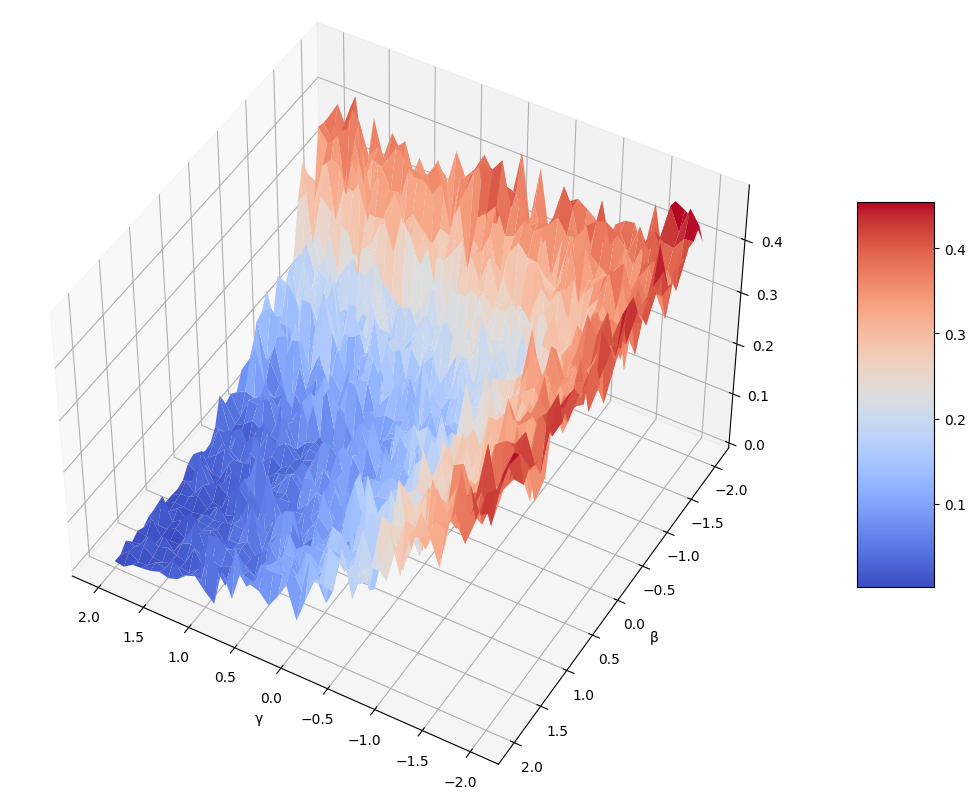

In [17]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
fig.set_figheight(10)
fig.set_figwidth(20)
X, Y = np.meshgrid(γ_range, β_range)
ax.view_init(elev=45, azim=120)
ax.set_xlabel("γ")
ax.set_ylabel("β")
surf = ax.plot_surface(X, Y, block_prob, cmap=plt.cm.coolwarm)
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()

In [310]:
SIM = Simulation(β=0.1, γ=0.1, debug=False)
Qlengths, block_prob, waiting_prob, avg_waiting_time = SIM.sim(T=10)

t = [r[0] for r in Qlengths]
Qs = [r[1] for r in Qlengths]
Qc = [r[2] for r in Qlengths]
Qt = [r[3] for r in Qlengths]

In [311]:
block_prob, waiting_prob, avg_waiting_time

(0.12685337726523888, 0.17994100294985252, 0.02079865675664827)

In [312]:
print(np.mean(Qs), np.var(Qs))
print(np.mean(Qc), np.var(Qc))
print(np.mean(Qt), np.var(Qt))

4.3630573248407645 17.217800136133537
17.990092002830856 14.074919524444184
3.6468506723283793 2.8469769890246717


In [315]:
window_size = 250
weights = np.ones(window_size) / window_size
Qs_smooth = np.convolve(Qs, weights, mode='valid')
Qc_smooth = np.convolve(Qc,  weights, mode='valid')
Qt_smooth = np.convolve(Qt, weights, mode='valid')

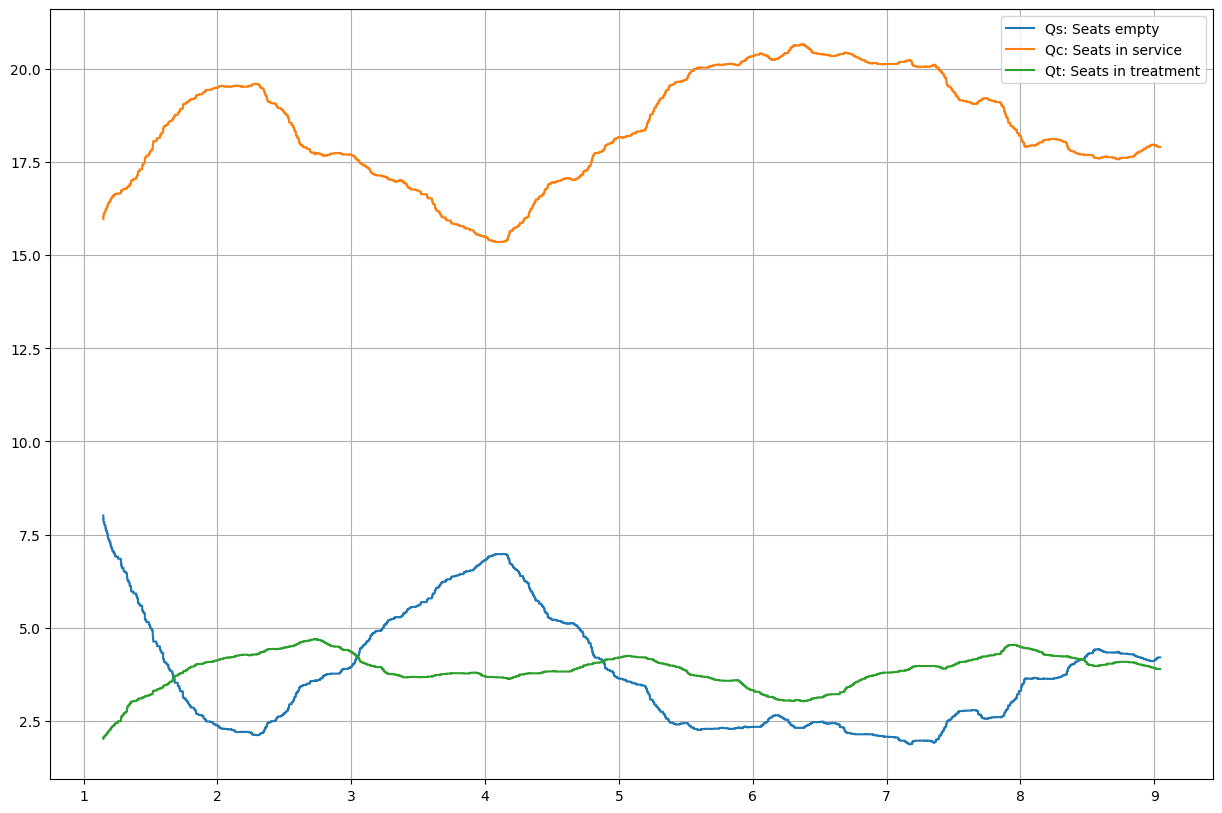

In [316]:
plt.figure(figsize=(15,10))
plt.grid()
plt.step(t[int(window_size/2):-int(window_size/2)+1],Qs_smooth)
plt.step(t[int(window_size/2):-int(window_size/2)+1],Qc_smooth)
plt.step(t[int(window_size/2):-int(window_size/2)+1],Qt_smooth)
plt.legend(["Qs: Seats empty","Qc: Seats in service","Qt: Seats in treatment"], loc="best")
plt.show()